In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from time import time
import matplotlib.ticker as tkr
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [ ]:
!pip install xgboost

In [ ]:
df = pd.read_csv('/content/household_power_consumption.txt', delimiter=';')

<ipython-input-43-74bf50eedd61>:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/household_power_consumption.txt', delimiter=';')


In [ ]:
print('Number of rows and columns:', df.shape)

df.head(5)

Number of rows and columns: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [ ]:
df.tail(5)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


In [ ]:
print("\nInformation about the dataframe:")
print(df.info())


Information about the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB
None


In [ ]:
# Convert the 'Date' and 'Time' columns to a single 'date_time' column
# by combining the two columns and converting to datetime format
df['date_time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df

<ipython-input-47-d1d0f950fbf4>:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,date_time
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,2006-12-16 17:28:00
...,...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0,2010-11-26 20:58:00
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0,2010-11-26 20:59:00
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0,2010-11-26 21:00:00
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0,2010-11-26 21:01:00


In [ ]:
# Convert the 'Global_active_power' column to numeric format
# and remove any rows with NaN values
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df = df.dropna(subset=['Global_active_power'])

In [ ]:
# Convert the 'date_time' column to datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

<ipython-input-49-d6eebfc30326>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_time'] = pd.to_datetime(df['date_time'])


In [ ]:
# Create new columns for year, quarter, month, and day
df['year'] = df['date_time'].apply(lambda x: x.year)
df['quarter'] = df['date_time'].apply(lambda x: x.quarter)
df['month'] = df['date_time'].apply(lambda x: x.month)
df['day'] = df['date_time'].apply(lambda x: x.day)

<ipython-input-50-852952fb722f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df['date_time'].apply(lambda x: x.year)
<ipython-input-50-852952fb722f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['quarter'] = df['date_time'].apply(lambda x: x.quarter)
<ipython-input-50-852952fb722f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

In [ ]:
# Keep only the columns 'date_time', 'Global_active_power', 'year', 'quarter', 'month', 'day'
df = df.loc[:,['date_time','Global_active_power', 'year','quarter','month','day']]

In [ ]:
# Sort the data by date_time in ascending order
df.sort_values('date_time', inplace=True, ascending=True)

In [ ]:
# Reset the index of the data
df = df.reset_index(drop=True)

In [ ]:
# Create a new column 'weekday' that indicates if the day is a weekday (1) or weekend (0)
df['weekday'] = df['date_time'].apply(lambda x: x.weekday() < 5).astype(int)

In [ ]:
# Print the number of rows and columns in the data
print('Number of rows and columns:', df.shape)

# Print the minimum and maximum date_time values
print('Minimum date_time:', df.date_time.min())
print('Maximum date_time:', df.date_time.max())

# Display the last 5 rows of the data
df.tail(5)

Number of rows and columns: (2049280, 7)
Minimum date_time: 2006-12-16 17:24:00
Maximum date_time: 2010-11-26 21:02:00


,date_time,Global_active_power,year,quarter,month,day,weekday
2049275,2010-11-26 20:58:00,0.946,2010,4,11,26,1
2049276,2010-11-26 20:59:00,0.944,2010,4,11,26,1
2049277,2010-11-26 21:00:00,0.938,2010,4,11,26,1
2049278,2010-11-26 21:01:00,0.934,2010,4,11,26,1
2049279,2010-11-26 21:02:00,0.932,2010,4,11,26,1


In [ ]:
import scipy.stats as stats

# Calculate the test statistics and p-value
stat, p = stats.normaltest(df.Global_active_power)

# Print the results
print('Statistics=%.3f, p=%.3f' % (stat, p))

# Set the significance level
alpha = 0.05

# Make a decision on the test result
if p > alpha:
    print('Data looks Gaussian (fail to reject H0)')
else:
    print('Data does not look Gaussian (reject H0)')

Statistics=724881.795, p=0.000
Data does not look Gaussian (reject H0)


<ipython-input-57-d9ea4d2d0f66>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Global_active_power,color='purple')


Kurtosis of normal distribution: 4.218671866132123
Skewness of normal distribution: 1.7862320846320818


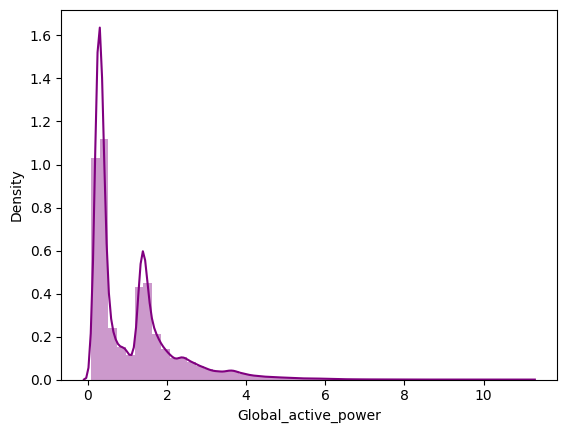

In [ ]:
sns.distplot(df.Global_active_power,color='purple')
print( 'Kurtosis of normal distribution: {}'.format(stats.kurtosis(df.Global_active_power)))
print( 'Skewness of normal distribution: {}'.format(stats.skew(df.Global_active_power)))

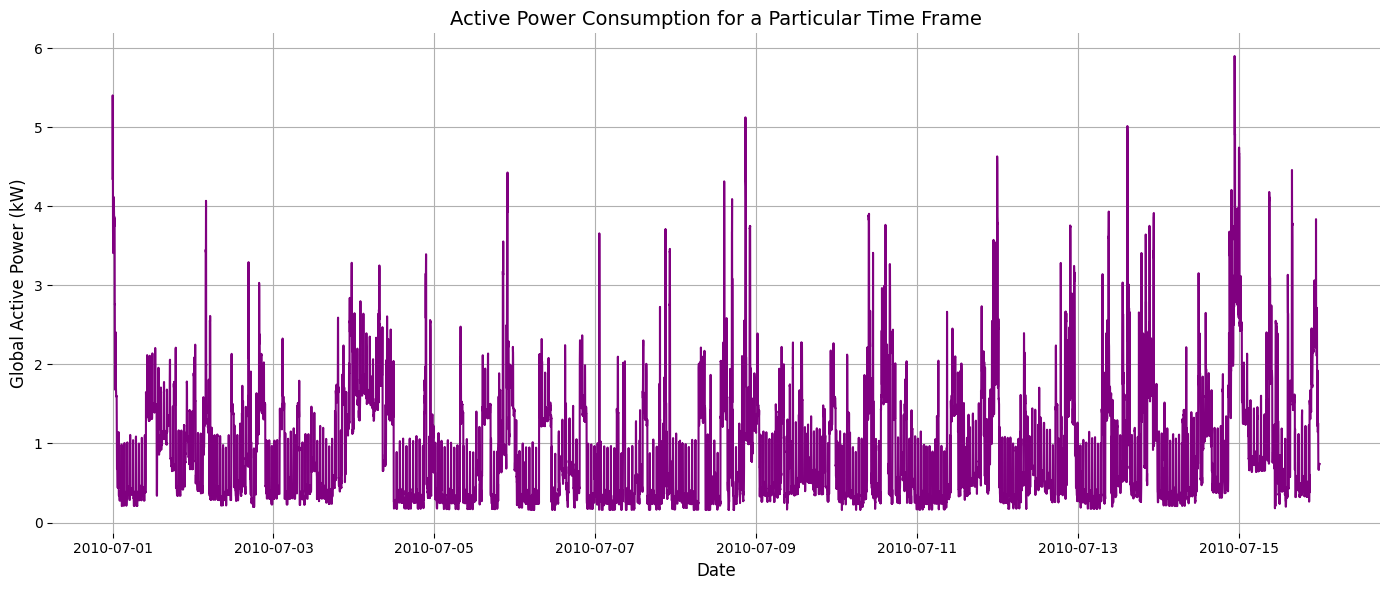

In [ ]:
data1 = df[(df.date_time >= '2010-07-01') & (df.date_time < '2010-7-16')]

plt.figure(figsize=(14,6))
plt.plot(data1.date_time, data1.Global_active_power, color='purple')
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.title('Active Power Consumption for a Particular Time Frame', fontsize=14)
plt.tight_layout()
plt.grid(True)
sns.despine(bottom=True, left=True)
plt.show()

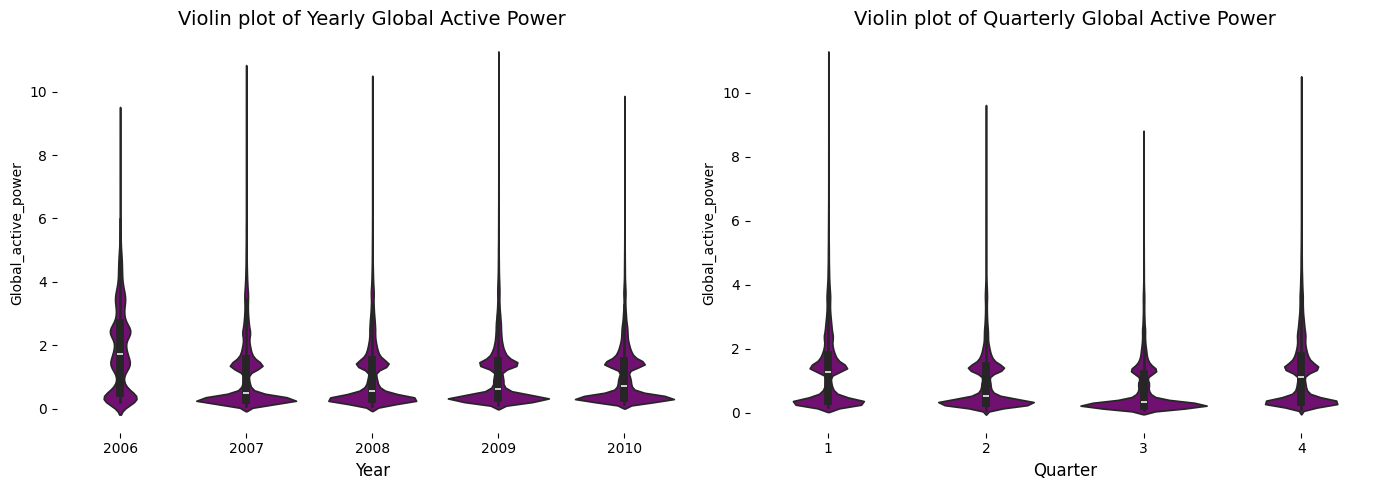

In [ ]:
plt.figure(figsize=(14,5))

# Plot the first subplot showing the violinplot of yearly global active power
plt.subplot(1,2,1)
# Adjust the subplot's width
plt.subplots_adjust(wspace=0.2)
# Create the violinplot using Seaborn's violinplot function
sns.violinplot(x="year", y="Global_active_power", data=df, color='purple')
# Label the x-axis
plt.xlabel('Year', fontsize=12)
# Add a title to the plot
plt.title('Violin plot of Yearly Global Active Power', fontsize=14)
# Remove the top and right spines of the plot
sns.despine(left=True, bottom=True)
# Add a tight layout to the plot
plt.tight_layout()

# Plot the second subplot showing the violinplot of quarterly global active power
plt.subplot(1,2,2)
# Create the violinplot using Seaborn's violinplot function
sns.violinplot(x="quarter", y="Global_active_power", data=df, color='purple')
# Label the x-axis
plt.xlabel('Quarter', fontsize=12)
# Add a title to the plot
plt.title('Violin plot of Quarterly Global Active Power', fontsize=14)
# Remove the top and right spines of the plot
sns.despine(left=True, bottom=True)
# Add a tight layout to the plot
plt.tight_layout()

                       count                           mean  \
date_time              21599  2010-07-08 11:59:01.572294912   
Global_active_power  21599.0                       0.846397   
year                 21599.0                         2010.0   
quarter              21599.0                            3.0   
month                21599.0                            7.0   
day                  21599.0                       7.999676   
weekday              21599.0                       0.733321   

                                     min                  25%  \
date_time            2010-07-01 00:00:00  2010-07-04 17:59:30   
Global_active_power                0.158                0.336   
year                              2010.0               2010.0   
quarter                              3.0                  3.0   
month                                7.0                  7.0   
day                                  1.0                  4.0   
weekday                              0.0

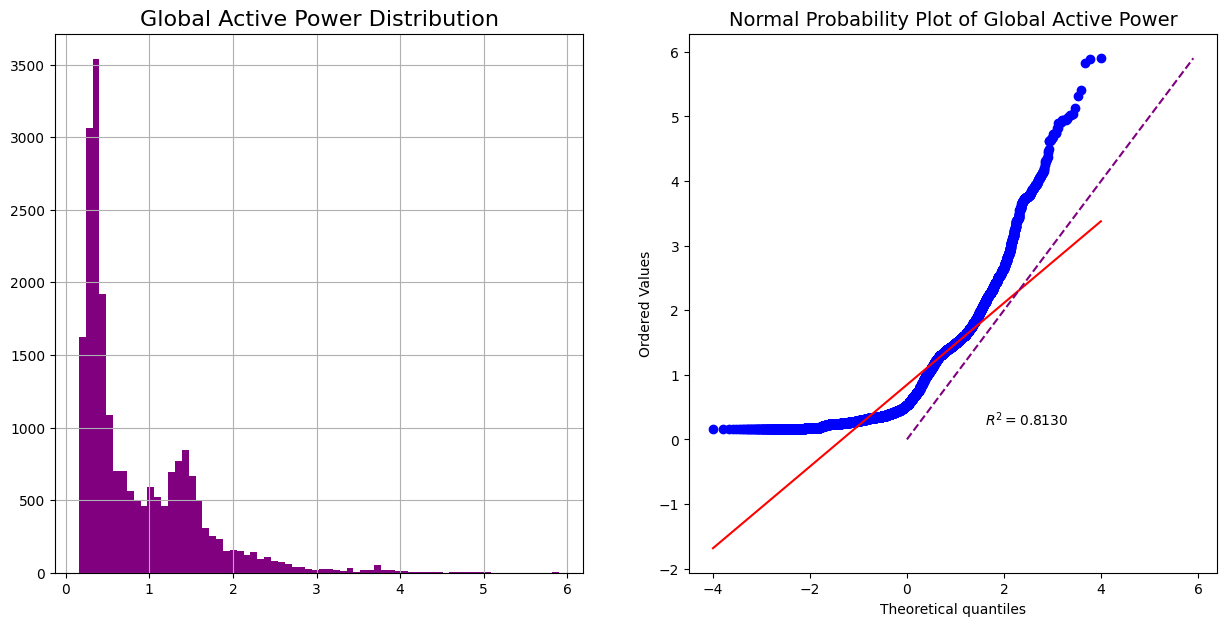

In [ ]:
# Plotting the histogram and normal probability plot for 'Global_active_power' column
plt.figure(figsize=(15,7))

# Histogram of 'Global_active_power' column
plt.subplot(1,2,1)
# Accessing the 'Global_active_power' column using .values to get numeric data
data1['Global_active_power'].hist(bins=70, color='purple')
plt.title('Global Active Power Distribution', fontsize=16)

# Normal Probability Plot of 'Global_active_power' column
plt.subplot(1,2,2)
# Create the normal probability plot using stats.probplot, accessing column by name
stats.probplot(data1['Global_active_power'].values, plot=plt, fit=True, rvalue=True)
# Add a line to the plot
plt.plot([0, max(data1['Global_active_power'])], [0, max(data1['Global_active_power'])], color='purple', linestyle='--')
plt.title('Normal Probability Plot of Global Active Power', fontsize=14)

# Printing the summary statistics of 'Global_active_power' column
print(data1.describe().T)

In [ ]:
data1=df.loc[:,['date_time','Global_active_power']]
data1.set_index('date_time',inplace=True)

<ipython-input-62-dffd83aa2262>:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ax3.plot(data1['Global_active_power'].resample('M').mean(), linewidth=1, color='purple')
<ipython-input-62-dffd83aa2262>:36: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ax4.plot(data1['Global_active_power'].resample('Q').mean(),linewidth=1, color='purple')
<ipython-input-62-dffd83aa2262>:46: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  ax5.plot(data1['Global_active_power'].resample('A').mean(),linewidth=1, color='purple')


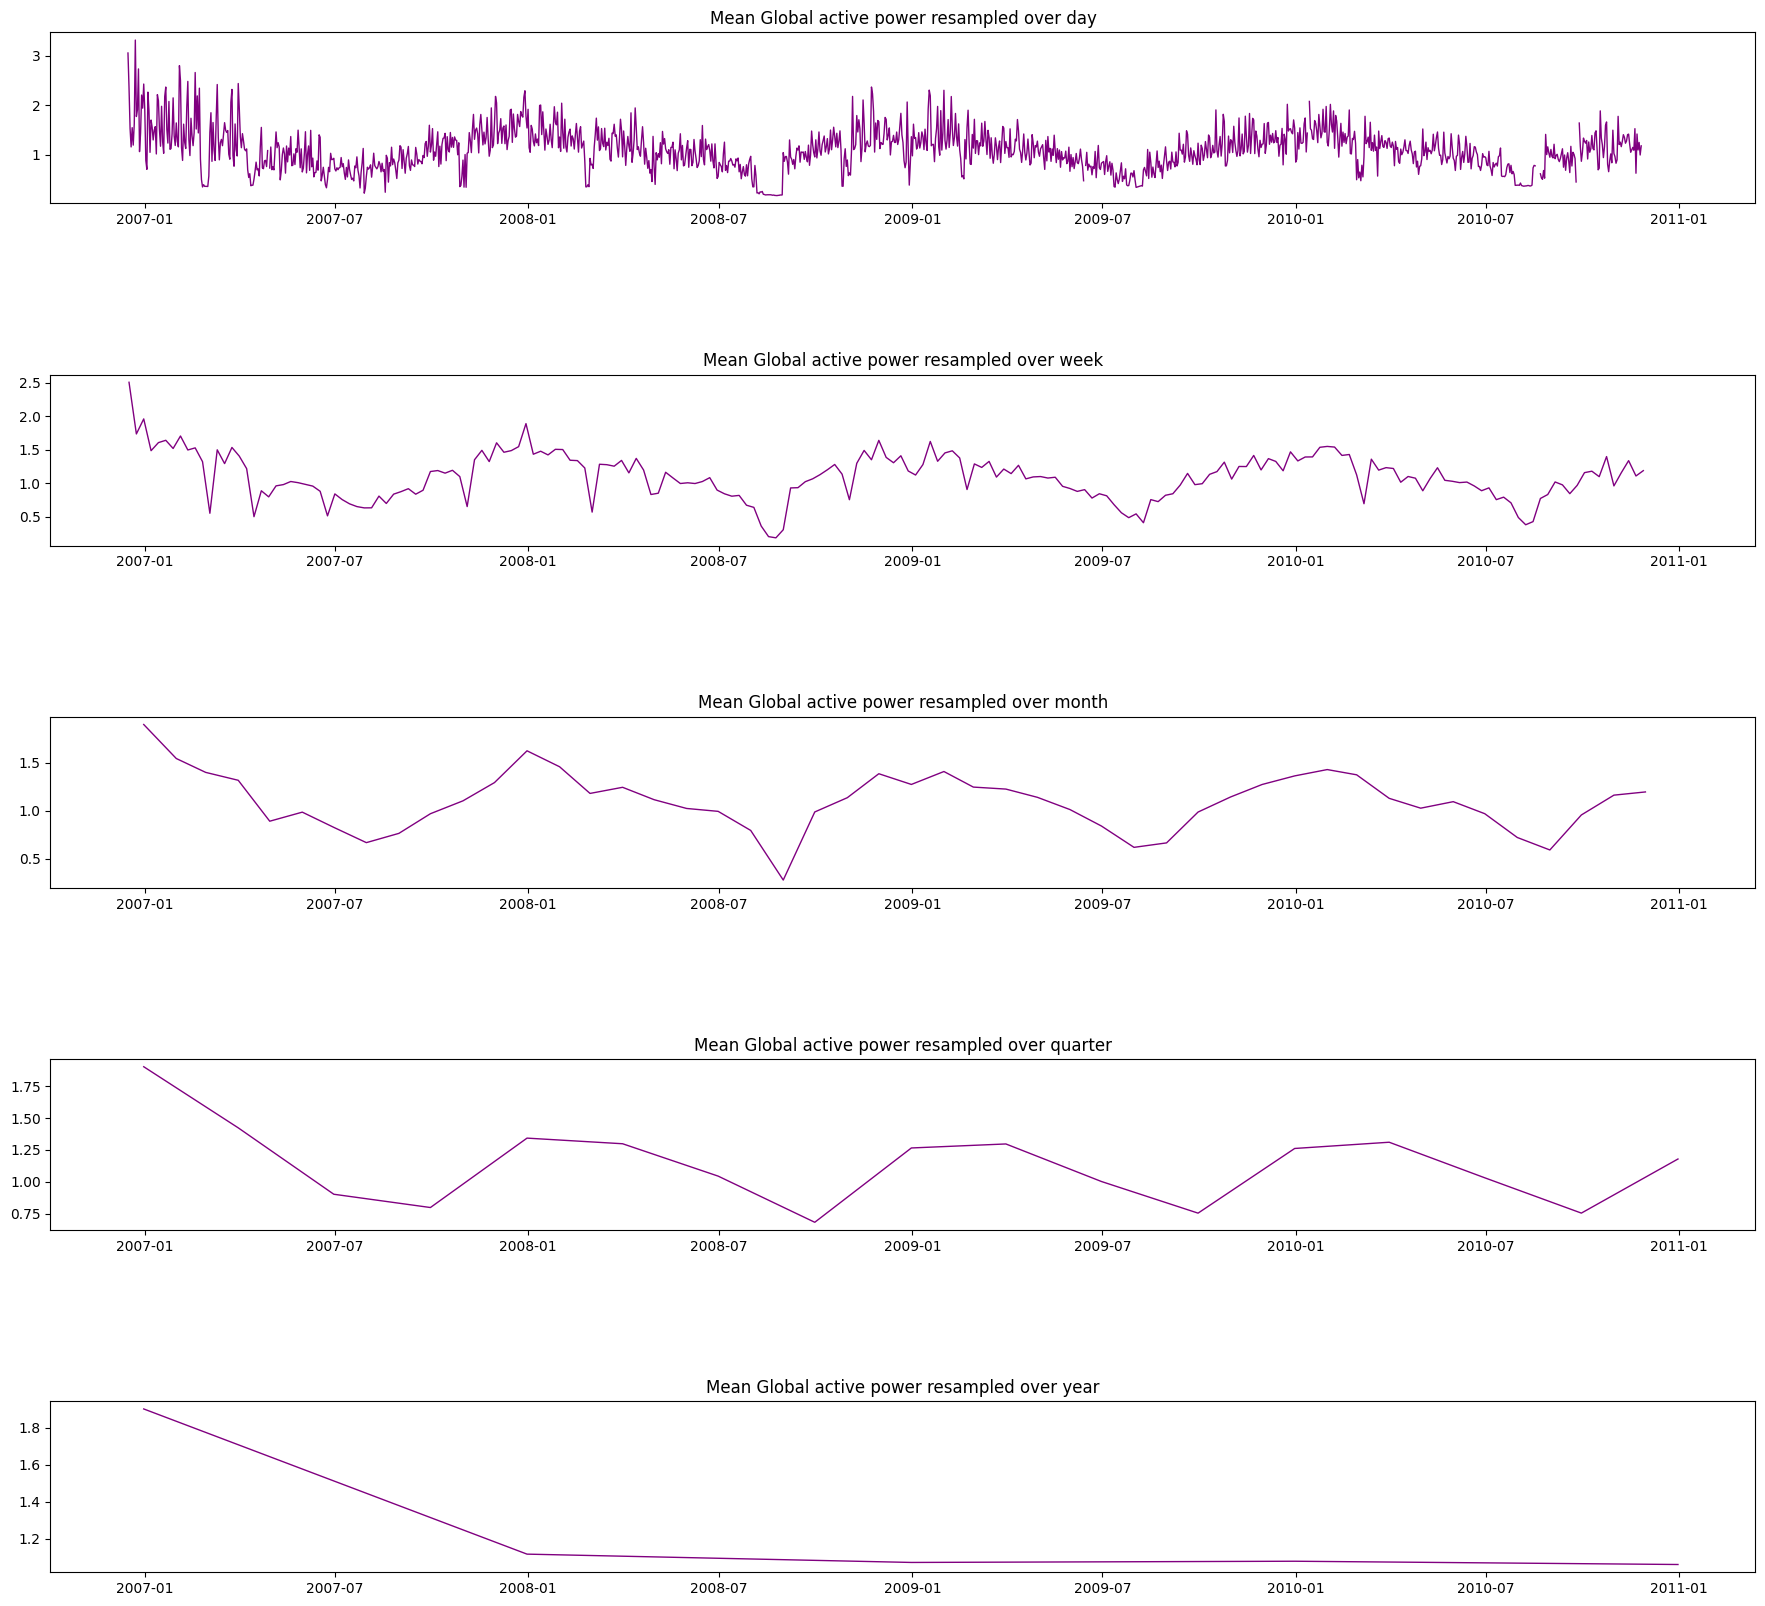

In [ ]:
# Create a figure with specified size
fig = plt.figure(figsize=(22,20))
# Adjust the subplot spacing
fig.subplots_adjust(hspace=1)

# Create first subplot
ax1 = fig.add_subplot(5,1,1)
# Plot the resampled mean of Global_active_power over day with different color
ax1.plot(data1['Global_active_power'].resample('D').mean(), linewidth=1, color='purple')
# Set the title for the subplot
ax1.set_title('Mean Global active power resampled over day')
# Set major tick parameters for the subplot
ax1.tick_params(axis='both', which='major')

# Create second subplot
ax2 = fig.add_subplot(5,1,2, sharex=ax1)
# Plot the resampled mean of Global_active_power over week with different color
ax2.plot(data1['Global_active_power'].resample('W').mean(), linewidth=1, color='purple')
# Set the title for the subplot
ax2.set_title('Mean Global active power resampled over week')
# Set major tick parameters for the subplot
ax2.tick_params(axis='both', which='major')

# Create third subplot
ax3 = fig.add_subplot(5,1,3, sharex=ax1)
# Plot the resampled mean of Global_active_power over month with different color
ax3.plot(data1['Global_active_power'].resample('M').mean(), linewidth=1, color='purple')
# Set the title for the subplot
ax3.set_title('Mean Global active power resampled over month')
# Set major tick parameters for the subplot
ax3.tick_params(axis='both', which='major')

# Create third subplot
ax4  = fig.add_subplot(5,1,4, sharex=ax1)
# Plot the resampled mean of Global_active_power over month with different color
ax4.plot(data1['Global_active_power'].resample('Q').mean(),linewidth=1, color='purple')
# Set the title for the subplot
ax4.set_title('Mean Global active power resampled over quarter')
# Set major tick parameters for the subplot
ax4.tick_params(axis='both', which='major')


# Create third subplot
ax5  = fig.add_subplot(5,1,5, sharex=ax1)
# Plot the resampled mean of Global_active_power over month with different color
ax5.plot(data1['Global_active_power'].resample('A').mean(),linewidth=1, color='purple')
# Set the title for the subplot
ax5.set_title('Mean Global active power resampled over year')
# Set major tick parameters for the subplot
ax5.tick_params(axis='both', which='major')

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. Define features and target
X = df[['year', 'quarter', 'month', 'day', 'weekday']]
y = df['Global_active_power']

# 2. Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Instantiate all models in a dict
models = {
    'Linear':           LinearRegression(),
    'Lasso':            Lasso(alpha=0.1),
    'Ridge':            Ridge(alpha=1.0),
    'KNN':              KNeighborsRegressor(n_neighbors=5),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':          XGBRegressor(n_estimators=100, random_state=42,
                                     objective='reg:squarederror'),
}

# 4. Fit, evaluate, and display results
for name, estimator in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),   # scale features
        ('model', estimator)
    ])
    # fit
    pipe.fit(X_train, y_train)

    # predictions
    train_preds = pipe.predict(X_train)
    test_preds  = pipe.predict(X_test)

    # compute R²
    train_r2 = r2_score(y_train, train_preds)
    test_r2  = r2_score(y_test, test_preds)

    # print summary metrics
    print(f"=== {name} ===")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test  R²: {test_r2:.4f}\n")

    # show a few actual vs. predicted on test set
    df_cmp = pd.DataFrame({
        'Actual':    y_test.reset_index(drop=True),
        'Predicted': pd.Series(test_preds).round(4)
    })
    print(df_cmp.head(), "\n")

=== Linear ===
Train R²: 0.0105
Test  R²: 0.0100

   Actual  Predicted
0   1.502     1.0120
1   0.374     1.2819
2   0.620     1.0577
3   0.280     1.1018
4   1.372     1.2139 

=== Lasso ===
Train R²: 0.0000
Test  R²: -0.0000

   Actual  Predicted
0   1.502     1.0917
1   0.374     1.0917
2   0.620     1.0917
3   0.280     1.0917
4   1.372     1.0917 

=== Ridge ===
Train R²: 0.0105
Test  R²: 0.0100

   Actual  Predicted
0   1.502     1.0120
1   0.374     1.2819
2   0.620     1.0577
3   0.280     1.1018
4   1.372     1.2139 

=== KNN ===
Train R²: -0.0220
Test  R²: -0.0260

   Actual  Predicted
0   1.502     0.8944
1   0.374     2.0716
2   0.620     0.5340
3   0.280     1.4044
4   1.372     2.2192 

=== RandomForest ===
Train R²: 0.1561
Test  R²: 0.1540

   Actual  Predicted
0   1.502     1.1055
1   0.374     2.3502
2   0.620     0.9342
3   0.280     1.1477
4   1.372     1.3902 

=== GradientBoosting ===
Train R²: 0.0926
Test  R²: 0.0912

   Actual  Predicted
0   1.502     1.2271
1   

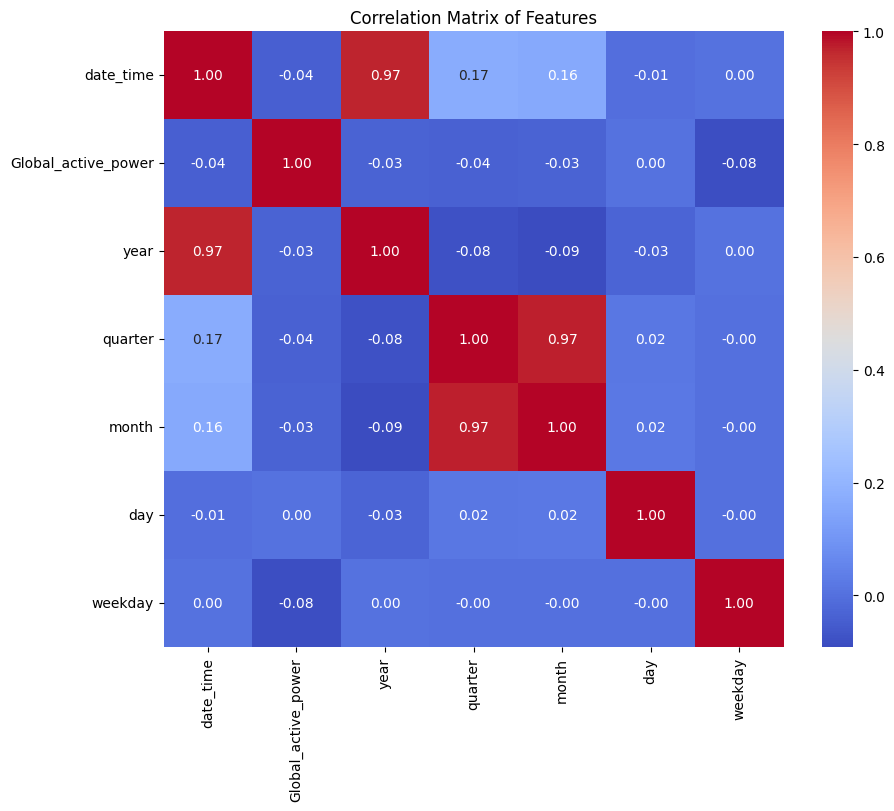

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [ ]:

scaler = MinMaxScaler()

features_to_scale = ['year', 'quarter', 'month', 'day', 'weekday']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print(df.head())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_to_scale = ['year', 'quarter', 'month', 'day', 'weekday']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print(df.head())


            date_time  Global_active_power  year  quarter  month  day  weekday
0 2006-12-16 17:24:00                4.216   0.0      1.0    1.0  0.5      0.0
1 2006-12-16 17:25:00                5.360   0.0      1.0    1.0  0.5      0.0
2 2006-12-16 17:26:00                5.374   0.0      1.0    1.0  0.5      0.0
3 2006-12-16 17:27:00                5.388   0.0      1.0    1.0  0.5      0.0
4 2006-12-16 17:28:00                3.666   0.0      1.0    1.0  0.5      0.0
            date_time  Global_active_power      year   quarter     month  \
0 2006-12-16 17:24:00                4.216 -2.156517  1.355299  1.619991   
1 2006-12-16 17:25:00                5.360 -2.156517  1.355299  1.619991   
2 2006-12-16 17:26:00                5.374 -2.156517  1.355299  1.619991   
3 2006-12-16 17:27:00                5.388 -2.156517  1.355299  1.619991   
4 2006-12-16 17:28:00                3.666 -2.156517  1.355299  1.619991   

        day   weekday  
0  0.032669 -1.593816  
1  0.032669 -1.593816

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. Define features and target
X = df[['year', 'quarter', 'month', 'day', 'weekday']]
y = df['Global_active_power']

# 2. Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Instantiate all models in a dict
models = {
    'Linear':           LinearRegression(),
    'Lasso':            Lasso(alpha=0.1),
    'Ridge':            Ridge(alpha=1.0),
    'KNN':              KNeighborsRegressor(n_neighbors=5),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':          XGBRegressor(n_estimators=100, random_state=42,
                                     objective='reg:squarederror'),
}

# 4. Fit, evaluate, and display results
for name, estimator in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),   # scale features
        ('model', estimator)
    ])
    # fit
    pipe.fit(X_train, y_train)

    # predictions
    train_preds = pipe.predict(X_train)
    test_preds  = pipe.predict(X_test)

    # compute R²
    train_r2 = r2_score(y_train, train_preds)
    test_r2  = r2_score(y_test, test_preds)

    # print summary metrics
    print(f"=== {name} ===")
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test  R²: {test_r2:.4f}\n")

    # show a few actual vs. predicted on test set
    df_cmp = pd.DataFrame({
        'Actual':    y_test.reset_index(drop=True),
        'Predicted': pd.Series(test_preds).round(4)
    })
    print(df_cmp.head(), "\n")


=== Linear ===
Train R²: 0.0105
Test  R²: 0.0100

   Actual  Predicted
0   1.502     1.0120
1   0.374     1.2819
2   0.620     1.0577
3   0.280     1.1018
4   1.372     1.2139 

=== Lasso ===
Train R²: 0.0000
Test  R²: -0.0000

   Actual  Predicted
0   1.502     1.0917
1   0.374     1.0917
2   0.620     1.0917
3   0.280     1.0917
4   1.372     1.0917 

=== Ridge ===
Train R²: 0.0105
Test  R²: 0.0100

   Actual  Predicted
0   1.502     1.0120
1   0.374     1.2819
2   0.620     1.0577
3   0.280     1.1018
4   1.372     1.2139 

=== KNN ===
Train R²: -0.0220
Test  R²: -0.0260

   Actual  Predicted
0   1.502     0.8944
1   0.374     2.0716
2   0.620     0.5340
3   0.280     1.4044
4   1.372     2.2192 

=== RandomForest ===
Train R²: 0.1561
Test  R²: 0.1540

   Actual  Predicted
0   1.502     1.1055
1   0.374     2.3502
2   0.620     0.9342
3   0.280     1.1477
4   1.372     1.3902 

=== GradientBoosting ===
Train R²: 0.0926
Test  R²: 0.0912

   Actual  Predicted
0   1.502     1.2271
1   

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# 1. Features & target
X = df[['year','quarter','month','day','weekday']]
y = df['Global_active_power']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Models and their grids
param_grids = {
    'Lasso': {
        'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
    },
    'Ridge': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0]
    },
    'KNN': {
        'model__n_neighbors': [3,5,7,9],
        'model__weights': ['uniform','distance'],
        'model__p': [1,2]
    },
    'RandomForest': {
        'model__n_estimators': [100,200],
        'model__max_depth': [None,10,20],
        'model__min_samples_leaf': [1,2,4]
    },
    'GradientBoosting': {
        'model__n_estimators': [100,200],
        'model__learning_rate': [0.01,0.1],
        'model__max_depth': [3,5]
    },
    'XGBoost': {
        'model__n_estimators': [100,200],
        'model__learning_rate': [0.01,0.1],
        'model__max_depth': [3,5],
        'model__subsample': [0.7,1.0]
    }
}

base_models = {
    'Linear': LinearRegression(),
    'Lasso':  Lasso(),
    'Ridge':  Ridge(),
    'KNN':    KNeighborsRegressor(),
    'RandomForest':     RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'XGBoost':          XGBRegressor(objective='reg:squarederror', random_state=42)
}

# 4. Run GridSearchCV for each model
results = []
for name, estimator in base_models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', estimator)
    ])

    if name in param_grids:
        grid = GridSearchCV(
            pipe,
            param_grids[name],
            scoring='r2',
            cv=5,
            n_jobs=-1
        )
    else:
        # LinearRegression has no hyperparameters to tune
        grid = pipe

    grid.fit(X_train, y_train)

    # extract best model
    best = grid.best_estimator_ if name in param_grids else grid
    train_r2 = r2_score(y_train, best.predict(X_train))
    test_r2  = r2_score(y_test,  best.predict(X_test))

    print(f"=== {name} ===")
    if name in param_grids:
        print("Best params:", grid.best_params_)
    print(f"Train R²: {train_r2:.4f}")
    print(f"Test  R²: {test_r2:.4f}\n")


=== Linear ===
Train R²: 0.0105
Test  R²: 0.0100

=== Lasso ===
Best params: {'model__alpha': 0.001}
Train R²: 0.0105
Test  R²: 0.0100

=== Ridge ===
Best params: {'model__alpha': 100.0}
Train R²: 0.0105
Test  R²: 0.0100

=== KNN ===
Best params: {'model__n_neighbors': 9, 'model__p': 2, 'model__weights': 'uniform'}
Train R²: 0.0646
Test  R²: 0.0618



In [ ]:
#Transform the Global_active_power column of the data DataFrame into a numpy array of float values

dataset = df.Global_active_power.values.astype('float32')
#Reshape the numpy array into a 2D array with 1 column

dataset = np.reshape(dataset, (-1, 1))
#Create an instance of the MinMaxScaler class to scale the values between 0 and 1

scaler = MinMaxScaler(feature_range=(0, 1))
#Fit the MinMaxScaler to the transformed data and transform the values

dataset = scaler.fit_transform(dataset)
#Split the transformed data into a training set (80%) and a test set (20%)

train_size = int(len(dataset) * 0.80)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

In [ ]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

In [ ]:
# reshape into X=t and Y=t+1
look_back = 30
X_train, Y_train = create_dataset(train, look_back)
X_test, Y_test = create_dataset(test, look_back)

In [ ]:
X_train.shape

In [ ]:
Y_train.shape

In [ ]:
# reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
X_train.shape

In [ ]:
# Defining the LSTM model
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from keras.callbacks import EarlyStopping
model = Sequential()

model.add(LSTM(100, input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.2))
model.add(Dense(1))

# Compiling the model with mean squared error as the loss function and using Adam optimizer
model.compile(loss='mean_squared_error', optimizer='adam')

# Fitting the model on training data and using early stopping to avoid overfitting
history = model.fit(X_train, Y_train, epochs=20, batch_size=1240, validation_data=(X_test, Y_test),
                    callbacks=[EarlyStopping(monitor='val_loss', patience=4)], verbose=1, shuffle=False)

model.summary()

In [ ]:
# make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)
# invert predictions
train_predict = scaler.inverse_transform(train_predict)
Y_train = scaler.inverse_transform([Y_train])
test_predict = scaler.inverse_transform(test_predict)
Y_test = scaler.inverse_transform([Y_test])

print('Train Mean Absolute Error:', mean_absolute_error(Y_train[0], train_predict[:,0]))
print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(Y_train[0], train_predict[:,0])))
print('Test Mean Absolute Error:', mean_absolute_error(Y_test[0], test_predict[:,0]))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(Y_test[0], test_predict[:,0])))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

aa=[x for x in range(200)]

plt.figure(figsize=(20,6))
sns.barplot(x=aa, y=Y_test[0][:200], label="actual", color='purple') # Changed plt.barplot to sns.barplot

# Plotting the predicted values using seaborn's barplot
sns.barplot(x=aa, y=test_predict[:,0][:200], label="prediction", color='red') # Changed plt.barplot to sns.barplot

# Removing the top spines
sns.despine(top=True)

# Adjusting the subplot location
plt.subplots_adjust(left=0.07)

plt.ylabel('Global_active_power', size=14)
plt.xlabel('Time step', size=14)
plt.legend(fontsize=16)
plt.show()

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class OptimizedGradientBoostingRegressor:
    def __init__(self, n_estimators=300, learning_rate=0.01, max_depth=5, subsample=0.8):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.subsample = subsample  # Subsampling ratio
        self.models = []
        self.initial_prediction = None

    def fit(self, X, y):
        self.initial_prediction = np.mean(y)
        y_pred = np.full(y.shape, self.initial_prediction, dtype=np.float32)  # Smaller data type

        for i in range(self.n_estimators):
            # Subsampling
            n_samples = int(self.subsample * X.shape[0])
            sample_indices = np.random.choice(X.shape[0], n_samples, replace=False)
            X_sample, y_sample = X[sample_indices], y[sample_indices]

            residuals = y_sample - y_pred[sample_indices]

            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X_sample, residuals)
            self.models.append(tree)

            y_pred += self.learning_rate * tree.predict(X)  # Vectorized update

    def predict(self, X):
        y_pred = np.full(X.shape[0], self.initial_prediction, dtype=np.float32)
        for tree in self.models:
            y_pred += self.learning_rate * tree.predict(X)  # Vectorized prediction
        return y_pred

In [ ]:
# Create some data
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
X, y = make_regression(n_samples=500, n_features=5, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = OptimizedGradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

aa=[x for x in range(200)]
# Creating a figure object with desired figure size
plt.figure(figsize=(20,6))

# Plotting the actual values using seaborn's barplot
sns.barplot(x=aa, y=Y_test[0][:200], label="actual", color='purple') # Changed plt.barplot to sns.barplot

# Plotting the predicted values using seaborn's barplot
sns.barplot(x=aa, y=test_predict[:,0][:200], label="prediction", color='red') # Changed plt.barplot to sns.barplot

# Removing the top spines
sns.despine(top=True)

# Adjusting the subplot location
plt.subplots_adjust(left=0.07)

plt.ylabel('Global_active_power', size=14)
plt.xlabel('Time step', size=14)
plt.legend(fontsize=16)
plt.show()

Tradational GBR
Time Complexity    O(T×m×d×logm)
Space Complexity   O(m×d+T×2L)

In [ ]:
# Same big O order as the classic gradient boosting — but
# subsampling reduces constant factors (making it faster in practice).
# Training Time   O(T×m×d×logm)
# Prediction Time      O(T×m test × L)
# Space   O(m×d+T×2 L)

# Subsampling (subsample = 0.8) → faster training with similar performance.

# Vectorized updates with NumPy → faster computations.

# Smaller dtype (float32) → less memory usage.

# Limited depth (max_depth=5) → Trees are shallow and fast to train/predict.

In [ ]:
from sklearn.metrics import r2_score
train_r2 = r2_score(y_test,  y_pred)
train_r2

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class XGBoostRegressorScratch:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, reg_lambda=1.0, gamma=0.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda  # L2 regularization term
        self.gamma = gamma  # Minimum loss reduction required to make a split
        self.models = []
        self.weights = []

    def _loss_gradient(self, y_true, y_pred):
        """First derivative (Gradient) of squared error loss."""
        return y_pred - y_true

    def _loss_hessian(self, y_true, y_pred):
        """Second derivative (Hessian) of squared error loss."""
        return np.ones_like(y_true)

    def fit(self, X, y):
        y_pred = np.zeros_like(y, dtype=np.float32)

        for i in range(self.n_estimators):
            grad = self._loss_gradient(y, y_pred)
            hess = self._loss_hessian(y, y_pred)

            # Approximate Newton step: fit grad/hess as labels
            pseudo_residual = -grad / (hess + 1e-6)

            # Train a regression tree on pseudo residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, pseudo_residual)
            update = tree.predict(X)

            # Weight the tree with learning rate
            y_pred += self.learning_rate * update

            self.models.append(tree)
            self.weights.append(self.learning_rate)

    def predict(self, X):
        y_pred = np.zeros(X.shape[0], dtype=np.float32)
        for tree, weight in zip(self.models, self.weights):
            y_pred += weight * tree.predict(X)
        return y_pred


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class XGBoostRegressorScratch:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, reg_lambda=1.0, gamma=0.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda  # L2 regularization term
        self.gamma = gamma  # Minimum loss reduction required to make a split
        self.models = []
        self.weights = []

    def _loss_gradient(self, y_true, y_pred):
        """First derivative (Gradient) of squared error loss."""
        return y_pred - y_true

    def _loss_hessian(self, y_true, y_pred):
        """Second derivative (Hessian) of squared error loss."""
        return np.ones_like(y_true)

    def fit(self, X, y):
        y_pred = np.zeros_like(y, dtype=np.float32)

        for i in range(self.n_estimators):
            grad = self._loss_gradient(y, y_pred)
            hess = self._loss_hessian(y, y_pred)

            # Approximate Newton step: fit grad/hess as labels
            pseudo_residual = -grad / (hess + 1e-6)

            # Train a regression tree on pseudo residuals
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, pseudo_residual)
            update = tree.predict(X)

            # Weight the tree with learning rate
            y_pred += self.learning_rate * update

            self.models.append(tree)
            self.weights.append(self.learning_rate)

    def predict(self, X):
        y_pred = np.zeros(X.shape[0], dtype=np.float32)
        for tree, weight in zip(self.models, self.weights):
            y_pred += weight * tree.predict(X)
        return y_pred


In [ ]:
# Simple demo
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Data
X, y = make_regression(n_samples=1000, n_features=10, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
xgb_scratch = XGBoostRegressorScratch(n_estimators=100, learning_rate=0.1, max_depth=3)
xgb_scratch.fit(X_train, y_train)

# Predictions
y_pred = xgb_scratch.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")


In [ ]:
from sklearn.metrics import r2_score
train_r2 = r2_score(y_test,  y_pred)
train_r2